# Handling Missing Data

Missing values are one of the most common and consequential data quality issues. How you handle them directly affects model performance — the wrong strategy introduces bias; ignoring them crashes most algorithms.

### What you will learn

| Section | Topic |
|---------|-------|
| 1 | Detecting and visualising missing data |
| 2 | Understanding missingness mechanisms (MCAR, MAR, MNAR) |
| 3 | Drop strategies — when removal is acceptable |
| 4 | Simple imputation — mean, median, mode, constant |
| 5 | Advanced imputation — KNN and Iterative (MICE) |
| 6 | Comparing strategies on downstream model performance |

**Dataset:** Titanic (via seaborn) — realistic mix of numeric and categorical columns with meaningful missingness patterns.

> **Prerequisite:** This notebook starts after data has been loaded. For loading best practices see `ml-materials/00_data_acquisition.ipynb`.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # must precede IterativeImputer import
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


---
## Section 1 — Detecting and Visualising Missing Data

Before deciding what to do with missing values, you need to know:
- **How many** values are missing per column
- **Which columns** are affected
- **Whether missingness is random or structured** (rows missing together)

In [8]:
# Load Titanic — a canonical dataset with realistic missing patterns
df = sns.load_dataset('titanic')
print(f'Shape: {df.shape}')
df.head()

URLError: <urlopen error [WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。>

In [ ]:
# --- Missing value summary ---
missing = (
    df.isnull()
      .sum()
      .rename('n_missing')
      .to_frame()
      .assign(pct_missing=lambda x: x['n_missing'] / len(df) * 100)
      .query('n_missing > 0')
      .sort_values('pct_missing', ascending=False)
)
print(missing.to_string())

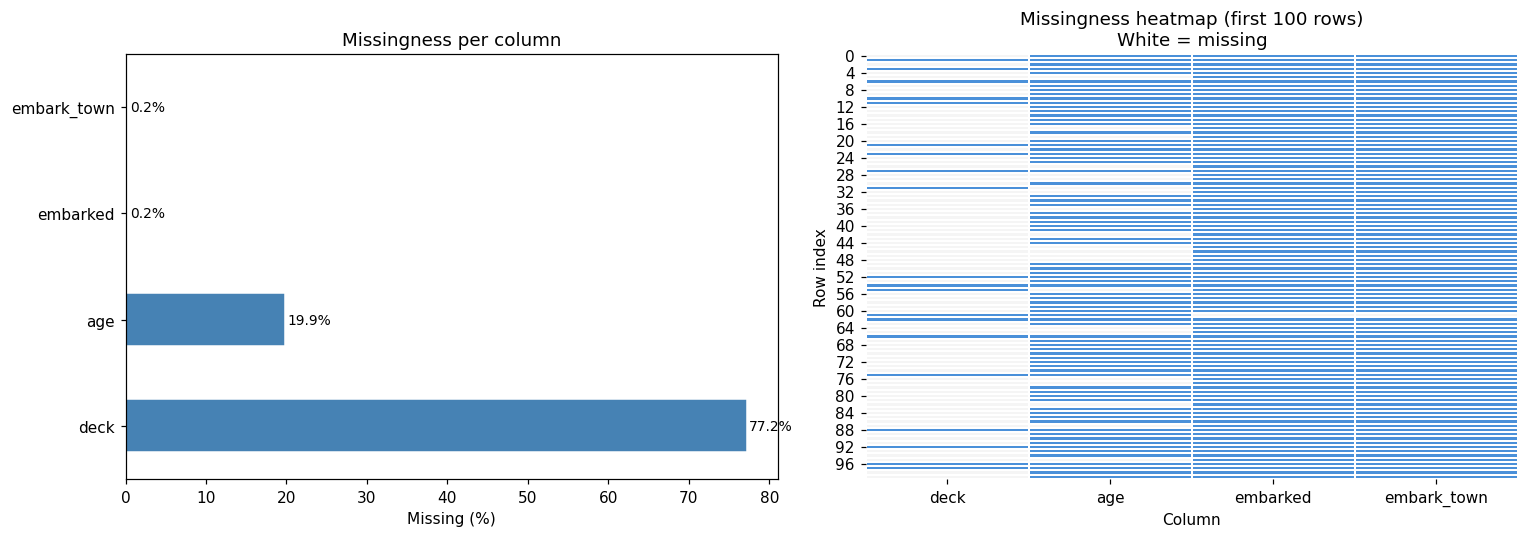

In [4]:
# --- Visualise missing data as a heatmap ---
# Each row = one observation; white = missing, coloured = present
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of missingness per column
missing['pct_missing'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missingness per column')
for bar, val in zip(axes[0].patches, missing['pct_missing']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Right: presence/absence heatmap — reveals row-level co-missingness
cols_with_missing = missing.index.tolist()
sample = df[cols_with_missing].isnull().astype(int).head(100)
sns.heatmap(sample, ax=axes[1], cbar=False,
            cmap=['#4a90d9', '#f5f5f5'], linewidths=0.3)
axes[1].set_title('Missingness heatmap (first 100 rows)\nWhite = missing')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Row index')

plt.tight_layout()
plt.show()

---
## Section 2 — Missingness Mechanisms

Not all missing data is created equal. The *reason* data is missing determines the best strategy:

| Mechanism | Definition | Example | Risk if ignored |
|-----------|-----------|---------|----------------|
| **MCAR** — Missing Completely At Random | Missingness is unrelated to any variable | Sensor glitch drops random rows | Safe to drop rows; imputation also fine |
| **MAR** — Missing At Random | Missingness depends on *other observed* variables | Older passengers less likely to report income | Imputation using other columns works well |
| **MNAR** — Missing Not At Random | Missingness depends on the *missing value itself* | High earners skip the income field | Simple imputation introduces bias; domain knowledge needed |

> **Rule of thumb:** Assume MAR unless you have strong evidence otherwise. MCAR is rarely true in practice; MNAR requires careful domain reasoning.

In [5]:
# Test for MCAR vs MAR: does missingness in 'age' correlate with other columns?
# If 'survived' rate differs between missing-age and non-missing-age groups → MAR

df['age_missing'] = df['age'].isnull().astype(int)

print('Survived rate by age missingness:')
print(df.groupby('age_missing')['survived'].mean().rename({0: 'age present', 1: 'age missing'}))

print('\nClass distribution by age missingness:')
print(df.groupby('age_missing')['pclass'].value_counts(normalize=True).unstack().rename(index={0: 'age present', 1: 'age missing'}))

Survived rate by age missingness:
age_missing
age present    0.406162
age missing    0.293785
Name: survived, dtype: float64

Class distribution by age missingness:
pclass              1         2         3
age_missing                              
age present  0.260504  0.242297  0.497199
age missing  0.169492  0.062147  0.768362


In [6]:
# Interpretation: if survived rate or class distribution differs between the two groups,
# age is MAR (its missingness correlates with other observed variables),
# which means KNN or MICE imputation will be more accurate than simple mean imputation.

df = df.drop(columns=['age_missing'])  # clean up the diagnostic column

---
## Section 3 — Drop Strategies

Dropping is the simplest approach — use it when:
- Missingness is MCAR and the fraction lost is small (< 5%)
- The column has > 50–70% missing and cannot be reliably imputed
- You have abundant data and can afford to lose rows

**Never drop first and ask questions later.** Always check how many rows/columns you lose and whether the remaining data is still representative.

In [7]:
# --- Drop rows with ANY missing value ---
df_drop_any = df.dropna()
print(f'Original rows  : {len(df)}')
print(f'After dropna() : {len(df_drop_any)}  ({len(df_drop_any)/len(df)*100:.1f}% retained)')

Original rows  : 891
After dropna() : 182  (20.4% retained)


In [8]:
# --- Drop rows only if missing in specific columns ---
# Keep rows where 'age' is present; accept missing in other columns
df_drop_age = df.dropna(subset=['age'])
print(f'After dropna(subset=[age]) : {len(df_drop_age)}  ({len(df_drop_age)/len(df)*100:.1f}% retained)')

After dropna(subset=[age]) : 714  (80.1% retained)


In [9]:
# --- Drop columns that exceed a missingness threshold ---
threshold = 0.40   # drop if > 40% missing
missing_frac = df.isnull().mean()
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
print(f'Columns with > {threshold*100:.0f}% missing: {cols_to_drop}')

df_col_dropped = df.drop(columns=cols_to_drop)
print(f'Columns before: {df.shape[1]}  →  after: {df_col_dropped.shape[1]}')

Columns with > 40% missing: ['deck']
Columns before: 15  →  after: 14


In [10]:
# --- thresh parameter: keep rows with at least N non-null values ---
# Useful when you want to be less aggressive than 'any'
n_required = df.shape[1] - 2   # allow at most 2 missing per row
df_thresh = df.dropna(thresh=n_required)
print(f'After dropna(thresh={n_required}) : {len(df_thresh)} rows')

After dropna(thresh=13) : 891 rows


---
## Section 4 — Simple Imputation

Imputation fills missing values using summary statistics or a constant.

| Strategy | Best for | Risk |
|----------|----------|------|
| **Mean** | Numeric, roughly symmetric distribution | Sensitive to outliers; compresses variance |
| **Median** | Numeric, skewed distribution or outliers present | More robust than mean |
| **Mode** | Categorical or discrete numeric | Can over-represent one value |
| **Constant** | When missing has semantic meaning (e.g. 0, 'Unknown') | Only valid if domain justifies the constant |

**Always fit the imputer on training data only.** Fitting on the full dataset leaks information about the test set.

In [11]:
# Work with a focused subset for clarity
work_cols = ['age', 'fare', 'embarked', 'survived']
df_work = df[work_cols].copy()
print('Missing counts before imputation:')
print(df_work.isnull().sum())

Missing counts before imputation:
age         177
fare          0
embarked      2
survived      0
dtype: int64


In [12]:
# --- Median imputation for numeric columns ---
median_imputer = SimpleImputer(strategy='median')
df_work[['age', 'fare']] = median_imputer.fit_transform(df_work[['age', 'fare']])

print(f'Imputed median for age  : {median_imputer.statistics_[0]:.2f}')
print(f'Imputed median for fare : {median_imputer.statistics_[1]:.2f}')
print(f"Missing in 'age' after  : {df_work['age'].isnull().sum()}")

Imputed median for age  : 28.00
Imputed median for fare : 14.45
Missing in 'age' after  : 0


In [13]:
# --- Most-frequent (mode) imputation for categoricals ---
mode_imputer = SimpleImputer(strategy='most_frequent')
df_work[['embarked']] = mode_imputer.fit_transform(df_work[['embarked']])

print(f"Imputed mode for embarked : '{mode_imputer.statistics_[0]}'")
print(f"Missing in 'embarked' after : {df_work['embarked'].isnull().sum()}")

Imputed mode for embarked : 'S'
Missing in 'embarked' after : 0


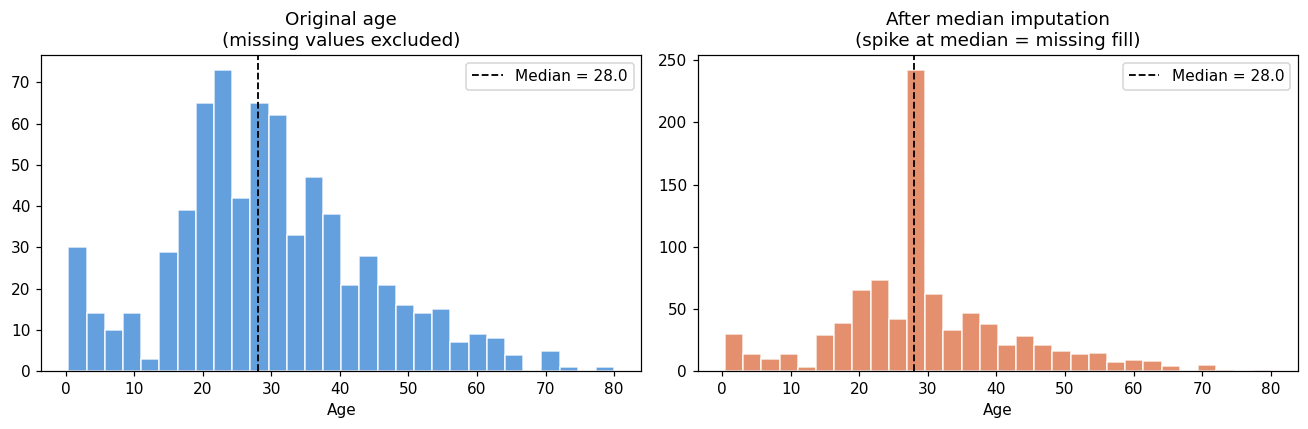

Note the spike at the median in the imputed distribution — a visible artefact of simple imputation.


In [14]:
# --- Visualise the effect of median imputation on the age distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

original_age = df['age'].dropna()
imputed_age  = df_work['age']

for ax, data, title, color in [
    (axes[0], original_age, 'Original age\n(missing values excluded)', '#4a90d9'),
    (axes[1], imputed_age,  'After median imputation\n(spike at median = missing fill)', '#e07b54'),
]:
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median = {data.median():.1f}')
    ax.set_title(title)
    ax.set_xlabel('Age')
    ax.legend()

plt.tight_layout()
plt.show()

print('Note the spike at the median in the imputed distribution — a visible artefact of simple imputation.')

---
## Section 5 — Advanced Imputation: KNN and Iterative (MICE)

Simple imputation ignores relationships between columns. Advanced methods exploit correlations to produce more realistic fill values.

### KNN Imputation
For each missing value, finds the *k* nearest neighbours (by other features) and uses their average. Respects local data structure.

- **Pro:** Better than mean/median when features are correlated
- **Con:** Slow on large datasets; sensitive to scale — always standardise first

### Iterative Imputation (MICE)
Models each feature with missing values as a function of all other features, cycling through until convergence. Scikit-learn's `IterativeImputer` uses a `BayesianRidge` regressor by default.

- **Pro:** Most statistically principled; captures complex inter-feature relationships
- **Con:** Computationally expensive; results can vary between runs (use `random_state`)

In [15]:
from sklearn.experimental import enable_iterative_imputer  # must import to enable
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

# Use a numeric-only subset for demonstration
numeric_cols = ['age', 'fare', 'parch', 'sibsp', 'pclass']
df_num = df[numeric_cols].copy()

print('Missing counts:')
print(df_num.isnull().sum())

Missing counts:
age       177
fare        0
parch       0
sibsp       0
pclass      0
dtype: int64


In [16]:
# --- KNN Imputation ---
# Scale first: KNN is distance-based, so all features must be on the same scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn_scaled = knn_imputer.fit_transform(df_scaled)

# Invert the scaling to get back original units
df_knn = pd.DataFrame(scaler.inverse_transform(df_knn_scaled), columns=numeric_cols)
print('KNN — missing after imputation:', df_knn.isnull().sum().sum())
print(f'KNN — mean age: {df_knn["age"].mean():.2f}  (original: {df_num["age"].mean():.2f}')

KNN — missing after imputation: 0
KNN — mean age: 29.81  (original: 29.70


In [17]:
# --- Iterative Imputation (MICE) ---
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median',  # starting point for each column
    imputation_order='roman',   # left-to-right column order
)
df_mice_arr = mice_imputer.fit_transform(df_num)
df_mice = pd.DataFrame(df_mice_arr, columns=numeric_cols)

print('MICE — missing after imputation:', df_mice.isnull().sum().sum())
print(f'MICE — mean age: {df_mice["age"].mean():.2f}  (original: {df_num["age"].mean():.2f}')

MICE — missing after imputation: 0
MICE — mean age: 29.29  (original: 29.70


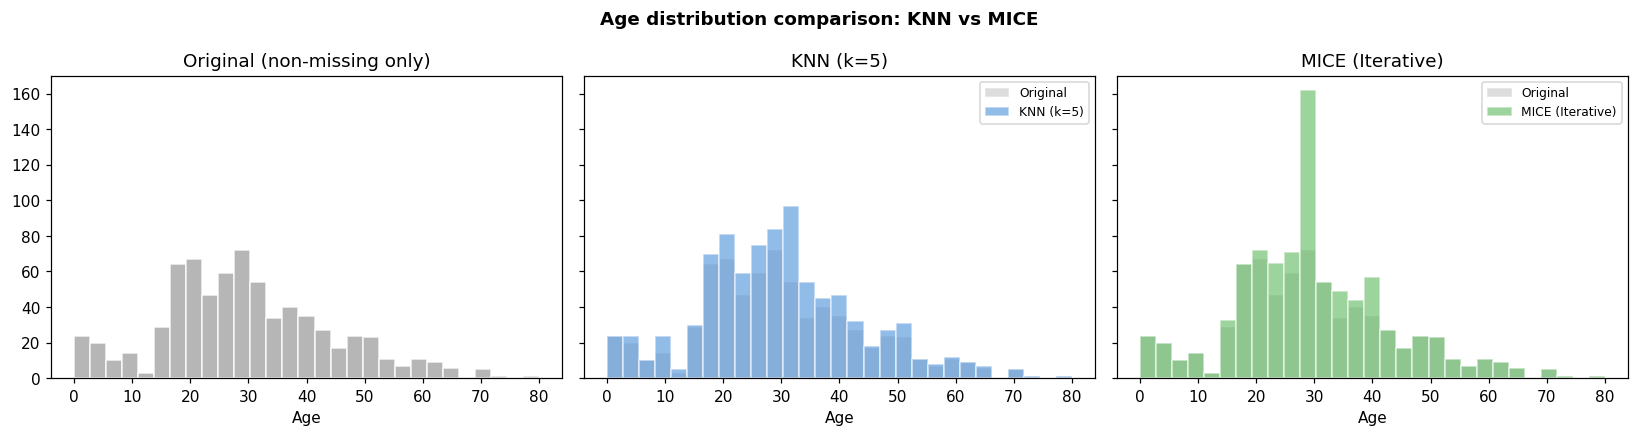

In [18]:
# --- Compare age distributions across strategies ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

original_known = df_num['age'].dropna()

strats = [
    (df_knn['age'], 'KNN (k=5)', '#4a90d9'),
    (df_mice['age'], 'MICE (Iterative)', '#5cb85c'),
]

bins = np.linspace(0, 80, 30)
axes[0].hist(original_known, bins=bins, color='#aaaaaa', edgecolor='white', alpha=0.85)
axes[0].set_title('Original (non-missing only)')
axes[0].set_xlabel('Age')

for ax, (data, label, color) in zip(axes[1:], strats):
    ax.hist(original_known, bins=bins, color='#aaaaaa', edgecolor='white', alpha=0.4, label='Original')
    ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.6, label=label)
    ax.set_title(label)
    ax.set_xlabel('Age')
    ax.legend(fontsize=8)

plt.suptitle('Age distribution comparison: KNN vs MICE', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — Comparing Strategies on Model Performance

The best imputation strategy is the one that leads to the best downstream model performance, not the one that looks best on a distribution plot. Here we compare all strategies using cross-validated accuracy on a survival prediction task.

In [19]:
from sklearn.experimental import enable_iterative_imputer  # noqa — already enabled above
from sklearn.impute import IterativeImputer

# Build a clean evaluation set: numeric features + target
eval_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df_eval = df[eval_cols + ['survived']].copy()

X = df_eval[eval_cols].values
y = df_eval['survived'].values

strategies = {
    'Mean'   : SimpleImputer(strategy='mean'),
    'Median' : SimpleImputer(strategy='median'),
    'KNN(5)' : KNNImputer(n_neighbors=5),
    'MICE'   : IterativeImputer(max_iter=10, random_state=42),
}

results = {}
for name, imputer in strategies.items():
    pipe = Pipeline([
        ('impute', imputer),
        ('model',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:10s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Mean        mean=0.6678  std=0.0194


Median      mean=0.6802  std=0.0194


KNN(5)      mean=0.6813  std=0.0163


MICE        mean=0.6824  std=0.0184


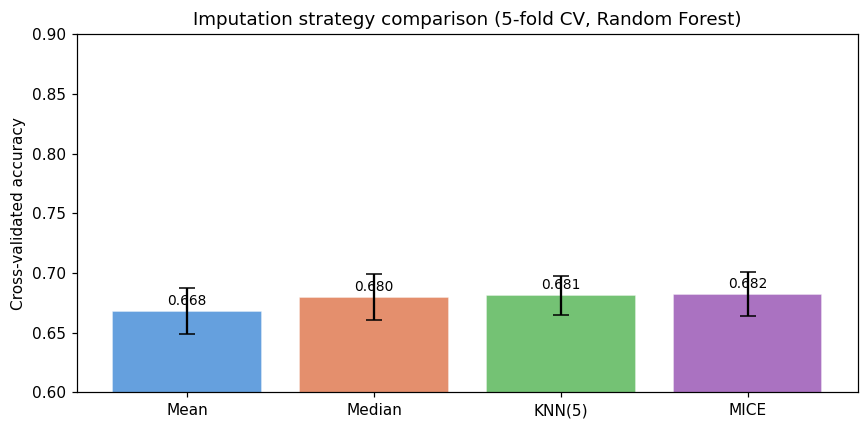

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=['#4a90d9', '#e07b54', '#5cb85c', '#9b59b6'],
              edgecolor='white', alpha=0.85)
ax.set_ylabel('Cross-validated accuracy')
ax.set_title('Imputation strategy comparison (5-fold CV, Random Forest)')
ax.set_ylim(0.6, 0.9)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Always profile missingness first** — know the count, percentage, and co-missingness pattern before deciding a strategy.
2. **Understand the mechanism** — MCAR allows safe dropping; MAR benefits from imputation using other features; MNAR requires domain knowledge.
3. **Dropping is rarely free** — even at 20% missingness, row deletion can introduce selection bias.
4. **Simple imputation compresses variance** — the spike in the distribution plot is a real artefact that can hurt models.
5. **KNN and MICE preserve inter-feature correlations** — they typically outperform simple strategies on correlated data.
6. **Always fit imputers on training data only** — fitting on the full dataset leaks test-set information.
7. **Evaluate imputation by downstream model performance**, not just distribution similarity.

---
## Exercises

1. Load the `seaborn` `planets` dataset and profile its missing values. Which columns are affected and by how much?
2. Check whether missingness in `orbital_period` is MCAR or MAR by comparing mean `mass` between rows with and without `orbital_period`.
3. Apply MICE imputation to the numeric columns and plot the `orbital_period` distribution before and after.
4. Build a regression pipeline to predict `orbital_period` from other features — compare MICE vs mean imputation in cross-validation.

CSV file loaded successfully
Dataset shape: (1035, 6)

First 5 rows:
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009

=== Exercise 1: Missing value analysis ===
                count    percent
mass              522  50.434783
distance          227  21.932367
orbital_period     43   4.154589
  - mass: missing 522 rows (50.43%)
  - distance: missing 227 rows (21.93%)
  - orbital_period: missing 43 rows (4.15%)

=== Exercise 2: Missingness mechanism ===
Mean mass when orbital_period is missing: nan
Mean mass when orbital_period is present: 2.6382
Conclusion: The mass difference is small, suggests MCAR


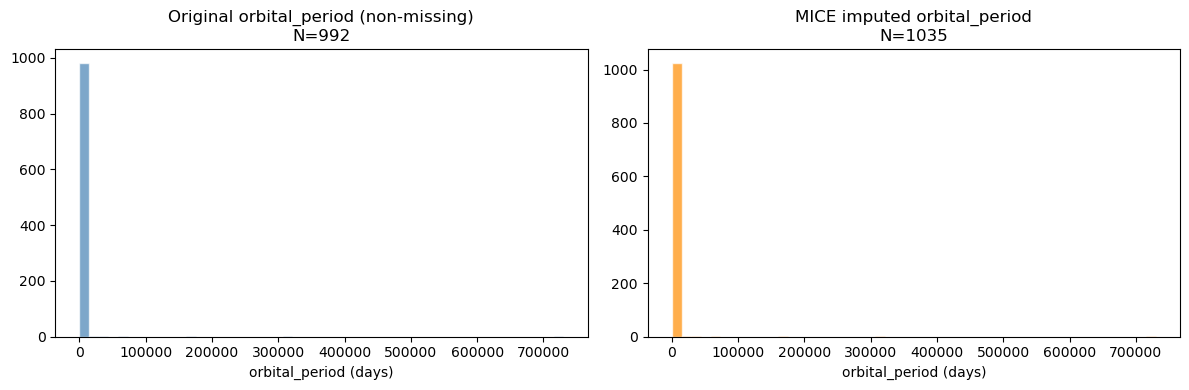


=== Exercise 3: MICE imputation completed, plot displayed ===

=== Exercise 4: Cross-validation R² comparison ===
Mean Imputation : -57.1245 ± 68.9688
MICE Imputation : -64.7549 ± 76.6270


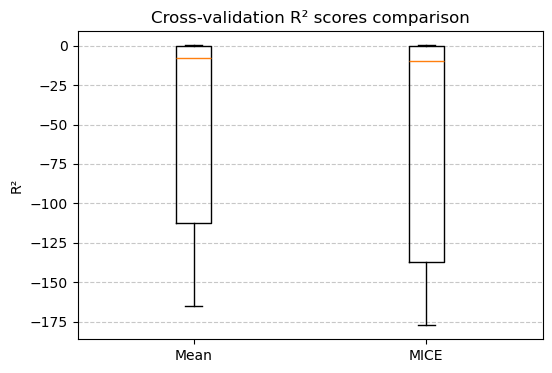

In [5]:
# ========== 1. Import libraries ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
import warnings
warnings.filterwarnings('ignore')

# ========== 2. Load data (CSV file) ==========
file_path = r'C:\Users\35111\Downloads\OneDrive_1_2026-5-26\planets.csv'
planets = pd.read_csv(file_path)
print("CSV file loaded successfully")
print("Dataset shape:", planets.shape)
print("\nFirst 5 rows:")
print(planets.head())

# ========== Exercise 1: Missing value analysis ==========
missing_cnt = planets.isnull().sum()
missing_pct = 100 * missing_cnt / len(planets)
missing_info = pd.DataFrame({'count': missing_cnt, 'percent': missing_pct})
missing_info = missing_info[missing_info['count'] > 0].sort_values('count', ascending=False)

print("\n=== Exercise 1: Missing value analysis ===")
print(missing_info.to_string())
for col in missing_info.index:
    print(f"  - {col}: missing {missing_info.loc[col, 'count']} rows ({missing_info.loc[col, 'percent']:.2f}%)")

# ========== Exercise 2: Missingness mechanism (MCAR vs MAR) ==========
planets['orbital_missing'] = planets['orbital_period'].isnull().astype(int)
mass_mean = planets.groupby('orbital_missing')['mass'].mean()
print("\n=== Exercise 2: Missingness mechanism ===")
print(f"Mean mass when orbital_period is missing: {mass_mean[1]:.4f}")
print(f"Mean mass when orbital_period is present: {mass_mean[0]:.4f}")
if abs(mass_mean[1] - mass_mean[0]) > 0.5:
    print("Conclusion: The mass difference is significant, suggests MAR (missingness related to mass)")
else:
    print("Conclusion: The mass difference is small, suggests MCAR")

# ========== Exercise 3: MICE imputation and distribution plot ==========
numeric_cols = planets.select_dtypes(include=[np.number]).columns.tolist()
if 'orbital_missing' in numeric_cols:
    numeric_cols.remove('orbital_missing')

X_num = planets[numeric_cols].copy()
imputer_mice = IterativeImputer(max_iter=20, random_state=42)
X_mice = imputer_mice.fit_transform(X_num)
df_mice = pd.DataFrame(X_mice, columns=numeric_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orig_orbital = planets['orbital_period'].dropna()
axes[0].hist(orig_orbital, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_title(f'Original orbital_period (non-missing)\nN={len(orig_orbital)}')
axes[0].set_xlabel('orbital_period (days)')

mice_orbital = df_mice['orbital_period']
axes[1].hist(mice_orbital, bins=50, color='darkorange', edgecolor='white', alpha=0.7)
axes[1].set_title(f'MICE imputed orbital_period\nN={len(mice_orbital)}')
axes[1].set_xlabel('orbital_period (days)')
plt.tight_layout()
plt.show()
print("\n=== Exercise 3: MICE imputation completed, plot displayed ===")

# ========== Exercise 4: Regression pipeline comparing MICE vs mean imputation ==========
data = planets.copy()
data = data.dropna(subset=['orbital_period'])   # target variable cannot be missing
y = data['orbital_period']
feature_cols = [col for col in numeric_cols if col != 'orbital_period']
X = data[feature_cols].copy()

pipe_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_mice = Pipeline([
    ('imputer', IterativeImputer(max_iter=20, random_state=42)),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores_mean = cross_val_score(pipe_mean, X, y, cv=cv, scoring='r2')
scores_mice = cross_val_score(pipe_mice, X, y, cv=cv, scoring='r2')

print("\n=== Exercise 4: Cross-validation R² comparison ===")
print(f"Mean Imputation : {scores_mean.mean():.4f} ± {scores_mean.std():.4f}")
print(f"MICE Imputation : {scores_mice.mean():.4f} ± {scores_mice.std():.4f}")

plt.figure(figsize=(6,4))
plt.boxplot([scores_mean, scores_mice], labels=['Mean', 'MICE'])
plt.title('Cross-validation R² scores comparison')
plt.ylabel('R²')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()